In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abbas829/okmon-with-stats-complete-generation-1-6-pokedex/Pokemon.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

******Loading files******

In [3]:
df=pd.read_csv("/kaggle/input/datasets/abbas829/okmon-with-stats-complete-generation-1-6-pokedex/Pokemon.csv")

In [4]:
df.head()

,number,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,Mega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,3,Gigantamax Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072 entries, 0 to 1071
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   number      1072 non-null   int64 
 1   name        1072 non-null   object
 2   type1       1072 non-null   object
 3   type2       574 non-null    object
 4   total       1072 non-null   int64 
 5   hp          1072 non-null   int64 
 6   attack      1072 non-null   int64 
 7   defense     1072 non-null   int64 
 8   sp_attack   1072 non-null   int64 
 9   sp_defense  1072 non-null   int64 
 10  speed       1072 non-null   int64 
 11  generation  1072 non-null   int64 
 12  legendary   1072 non-null   bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 101.7+ KB


In [6]:
df.describe()

,number,total,hp,attack,defense,sp_attack,sp_defense,speed,generation
count,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000
mean,445.219216,440.885261,70.486940,80.938433,74.968284,73.273321,72.476679,68.792910,4.294776
std,267.772806,121.379077,26.868039,32.463582,31.208059,32.643119,27.934253,30.076281,2.346472
min,1.000000,175.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,0.000000
25%,209.750000,330.000000,50.000000,56.000000,52.000000,50.000000,50.000000,45.000000,2.000000
50%,442.500000,460.500000,68.000000,80.000000,70.000000,65.000000,70.000000,65.000000,4.000000
75%,681.250000,519.250000,84.000000,100.000000,90.000000,95.000000,90.000000,90.000000,6.000000
max,898.000000,1125.000000,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000,8.000000


In [7]:
df.drop(columns="number",inplace=True)

In [8]:
df['legendary']=df['legendary'].replace({False:0,True:1})

In [9]:
df['type1'].unique(),df['type2'].unique()

(array(['Grass', 'Fire', 'Water', 'Blastoise', 'Bug', 'Normal', 'Dark',
        'Poison', 'Electric', 'Ground', 'Ice', 'Fairy', 'Steel',
        'Fighting', 'Psychic', 'Rock', 'Ghost', 'Dragon', 'Flying',
        'Graass'], dtype=object),
 array(['Poison', nan, 'Flying', 'Dragon', 'Water', 'Normal', 'Psychic',
        'Steel', 'Ground', 'Fairy', 'Grass', 'Fighting', 'Electric', 'Ice',
        'Dark', 'Ghost', 'Rock', 'Fire', 'Bug'], dtype=object))

In [10]:
df['type1']=df['type1'].replace("Graass","Grass")

In [11]:
df['type1']=df['type1'].replace("Blastoise","Water")
df.loc[
    (df['type1'] == 'Water') & (df['type2'] == 'Water'),
    'type2'
] = np.nan


In [12]:
data=['Grass', 'Fire', 'Water', 'Blastoise', 'Bug', 'Normal', 'Dark',
        'Poison', 'Electric', 'Ground', 'Ice', 'Fairy', 'Steel',
        'Fighting', 'Psychic', 'Rock', 'Ghost', 'Dragon', 'Flying']

for da in data:
    df[da]=(df['type1'].str.contains(da, na=False) |
        df['type2'].str.contains(da, na=False)).astype(int)

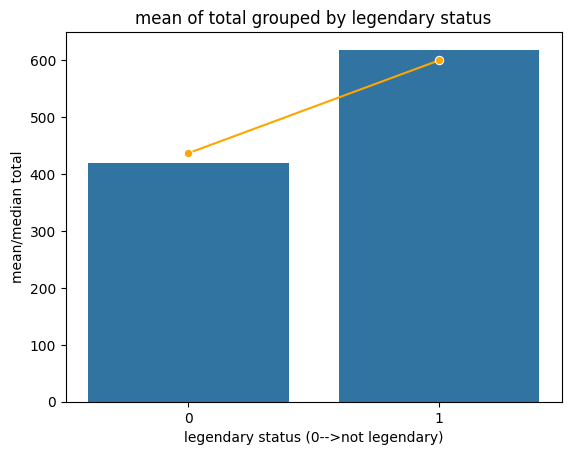

In [13]:
legendary_group=df.groupby("legendary")
legendary_group_mean=legendary_group['total'].mean()
legendary_group_median=legendary_group['total'].median()
plt.title("mean of total grouped by legendary status")
plt.xlabel("legendary status (0-->not legendary)")
plt.ylabel("mean/median total")
sns.barplot(x=legendary_group_mean.index,y=legendary_group_mean.values)
sns.lineplot(x=legendary_group_median.index,y=legendary_group_median.values,color="orange",marker="o")
plt.show()

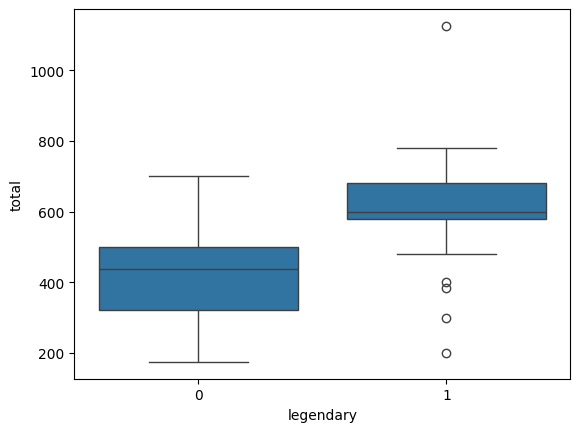

In [14]:
sns.boxplot(x='legendary', y='total', data=df)
plt.show()

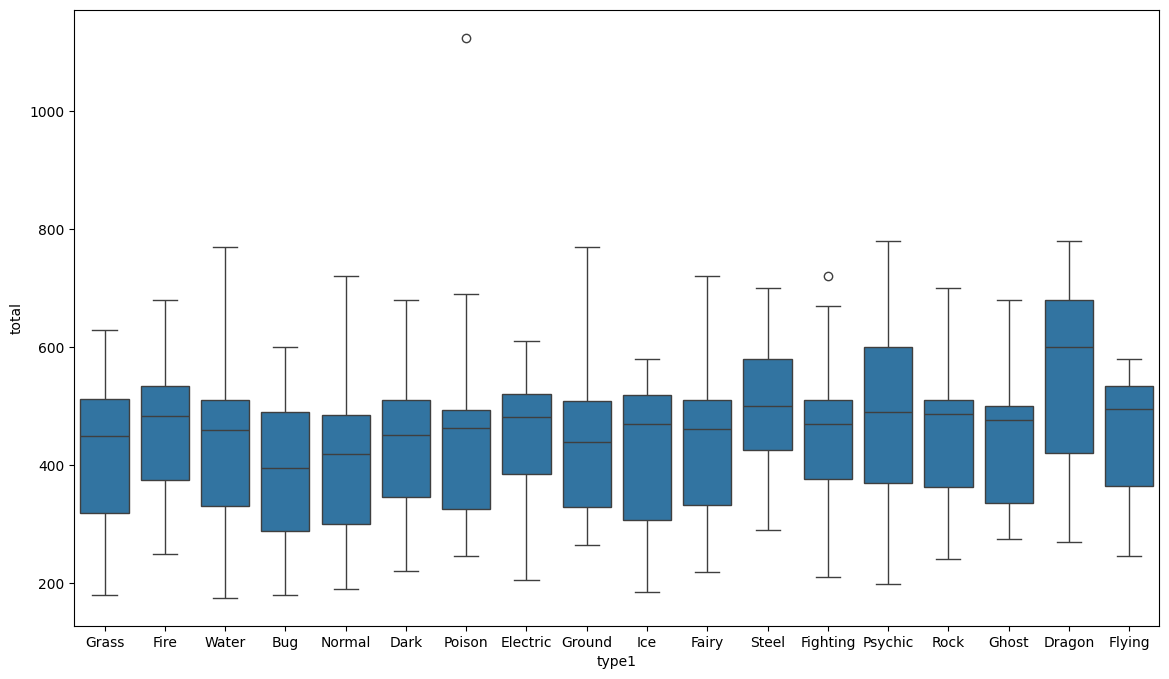

In [15]:
plt.figure(figsize=(14,8))
sns.boxplot(x='type1', y='total', data=df)
plt.show()

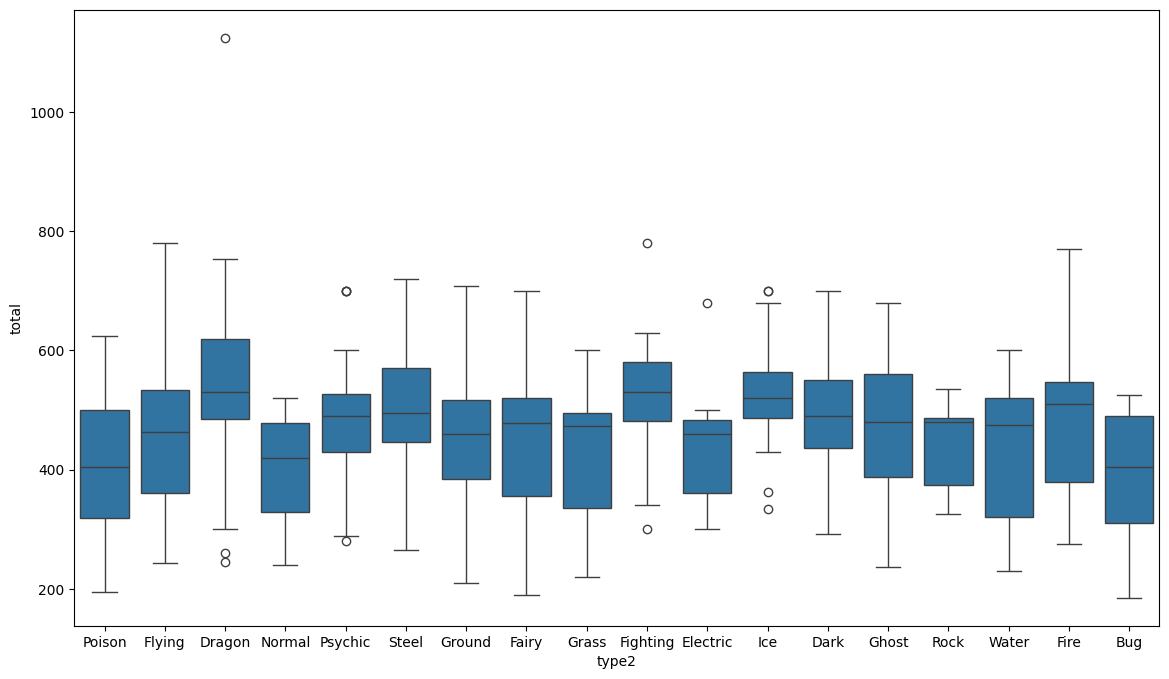

In [16]:
plt.figure(figsize=(14,8))
sns.boxplot(x='type2', y='total', data=df)
plt.show()

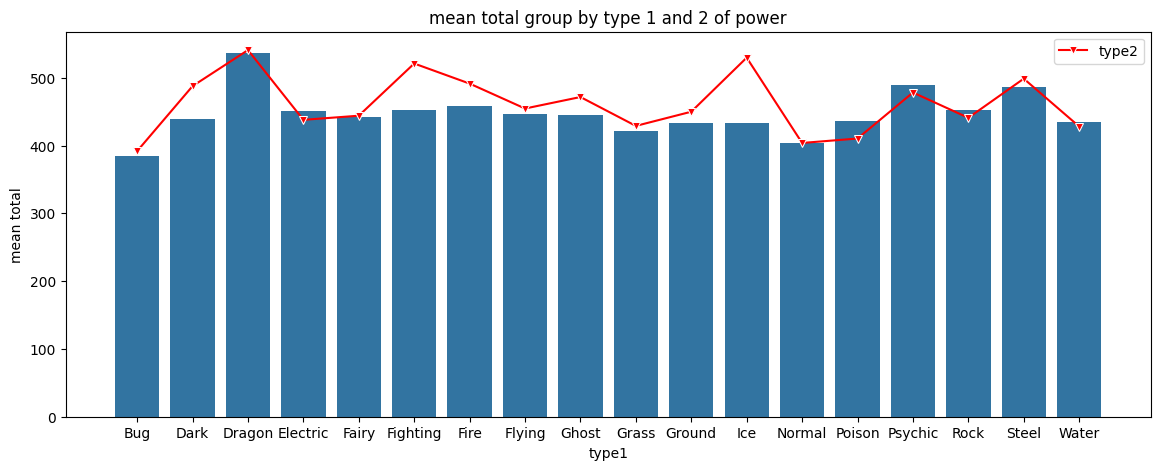

In [17]:
type1_group=df.groupby("type1")
type2_group=df.groupby("type2")
plt.figure(figsize=(14,5))
plt.title("mean total group by type 1 and 2 of power")
plt.ylabel("mean total")
sns.barplot(x=type1_group['total'].mean().index,y=type1_group['total'].mean().values)
sns.lineplot(x=type2_group['total'].mean().index,y=type2_group['total'].mean().values,color="red",marker="v",label="type2")
plt.show()

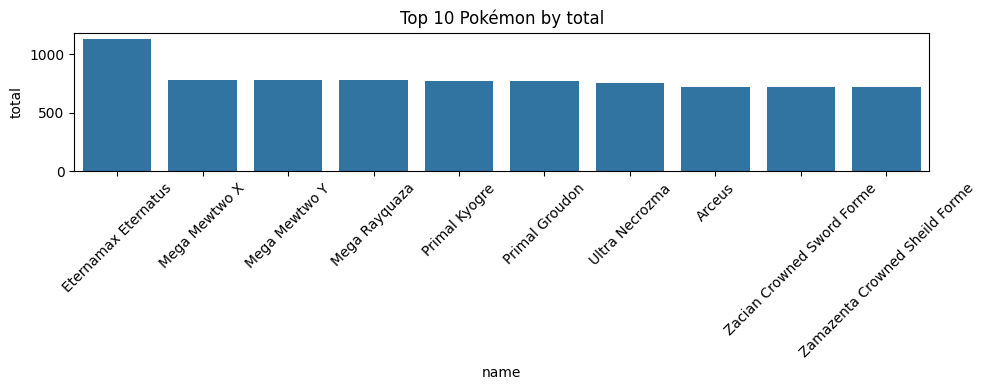

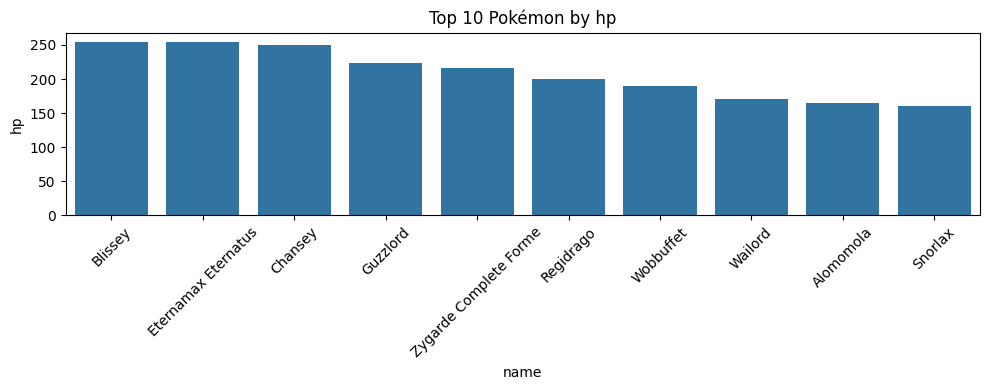

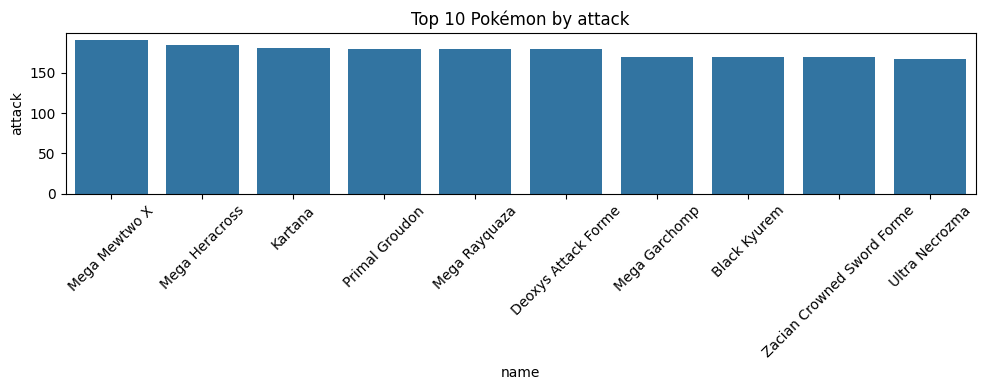

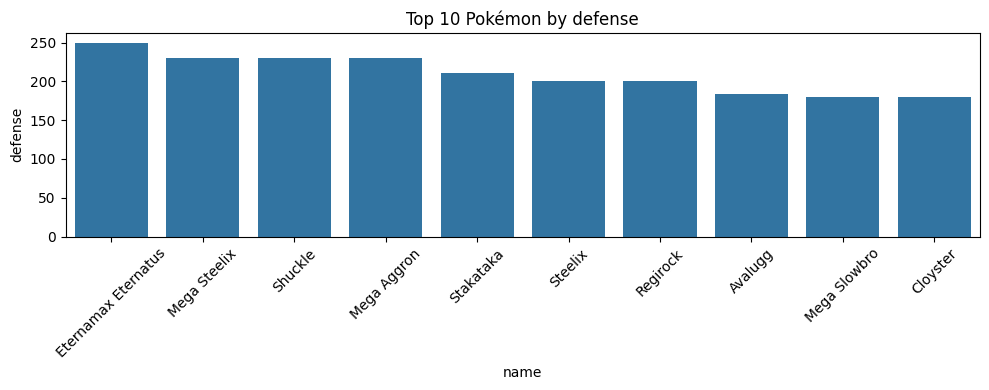

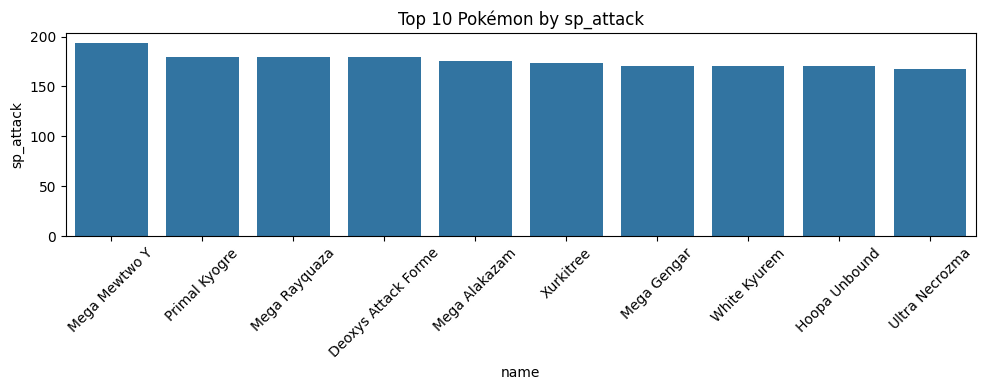

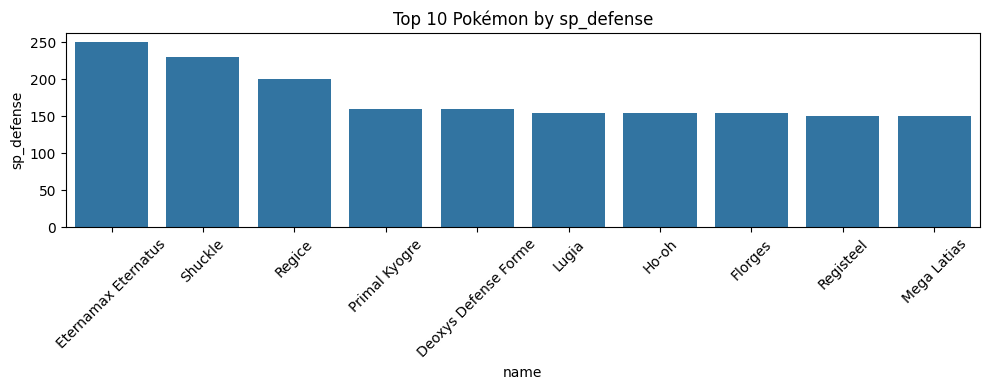

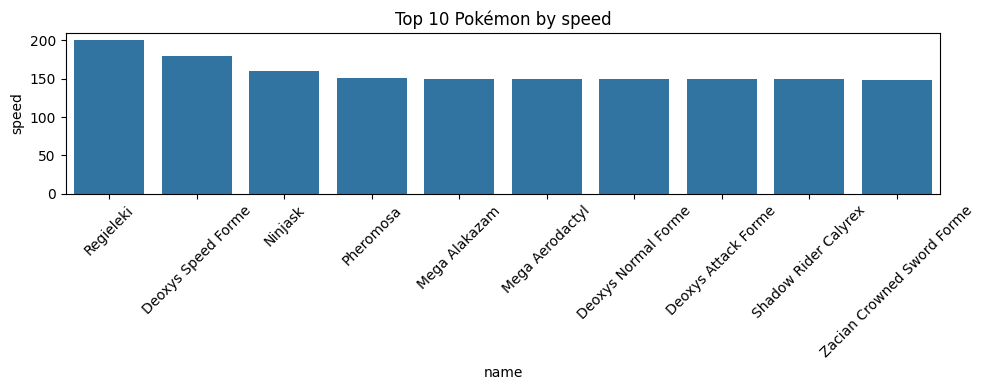

In [18]:
data2=['total',	'hp','attack','defense','sp_attack','sp_defense','speed']
for col in data2:
    group = df.nlargest(10, col)

    plt.figure(figsize=(10,4))
    sns.barplot(x=group['name'], y=group[col])

    plt.title(f"Top 10 Pokémon by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

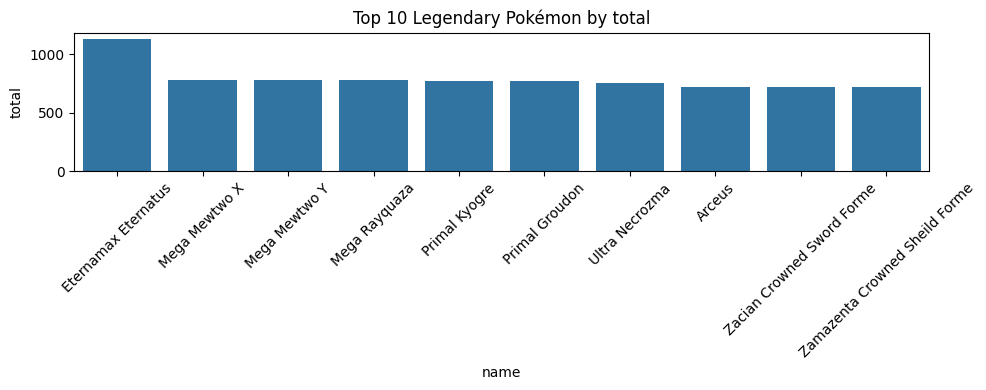

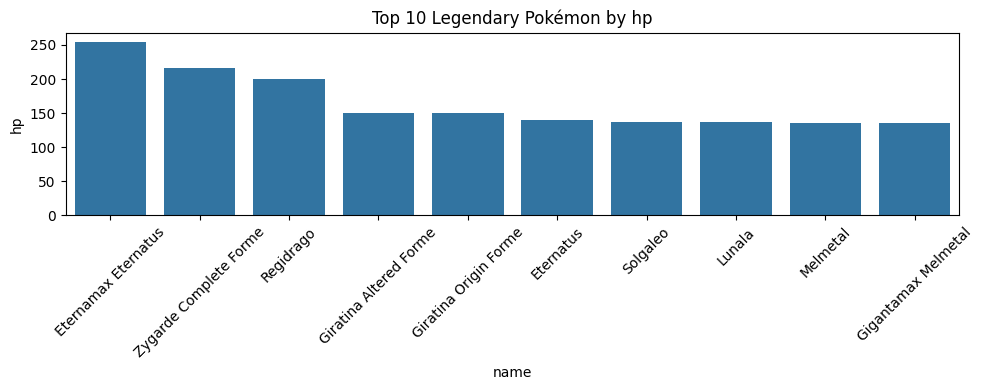

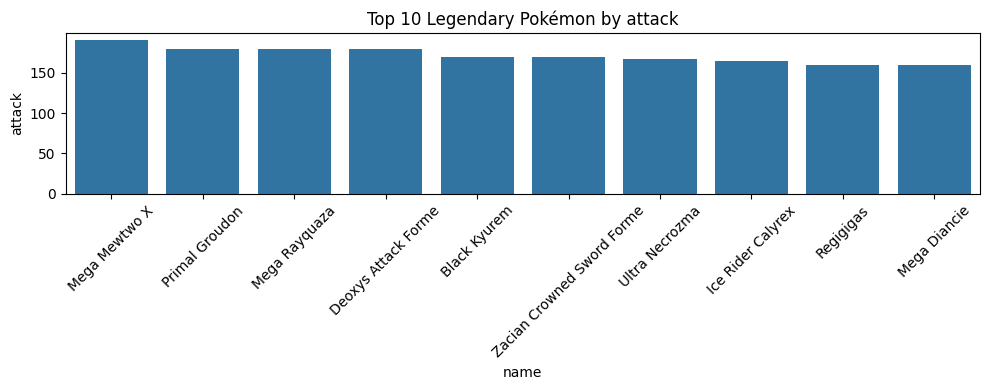

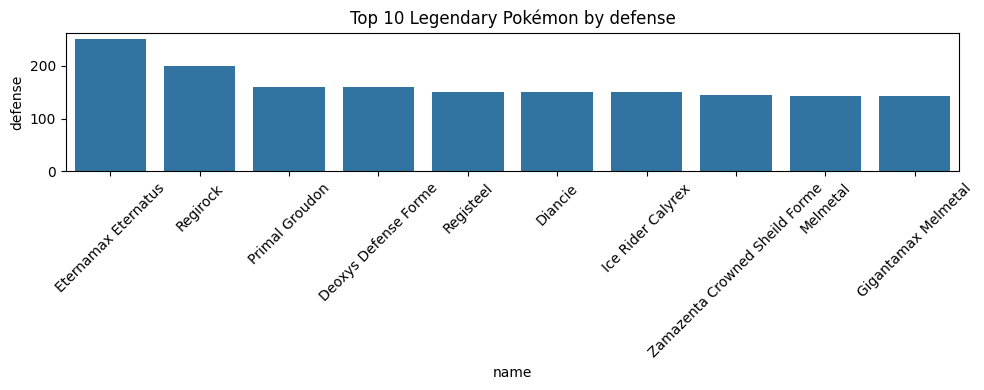

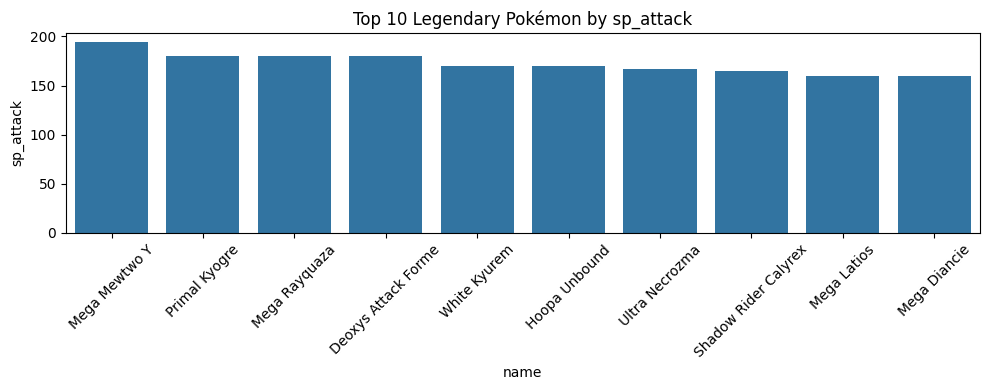

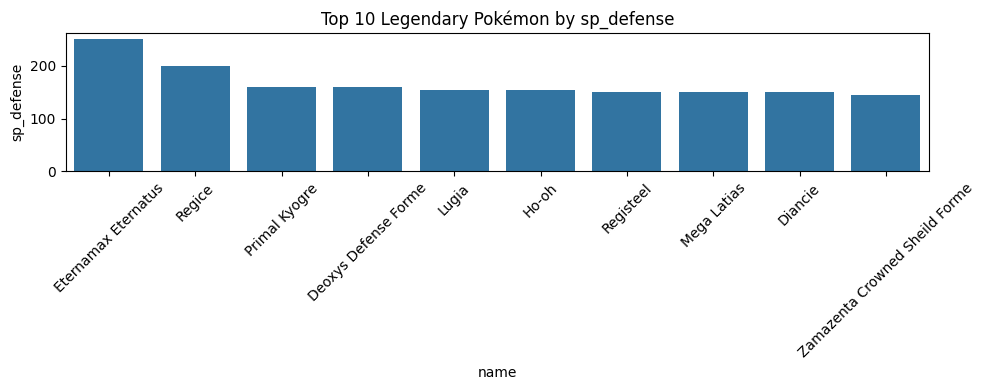

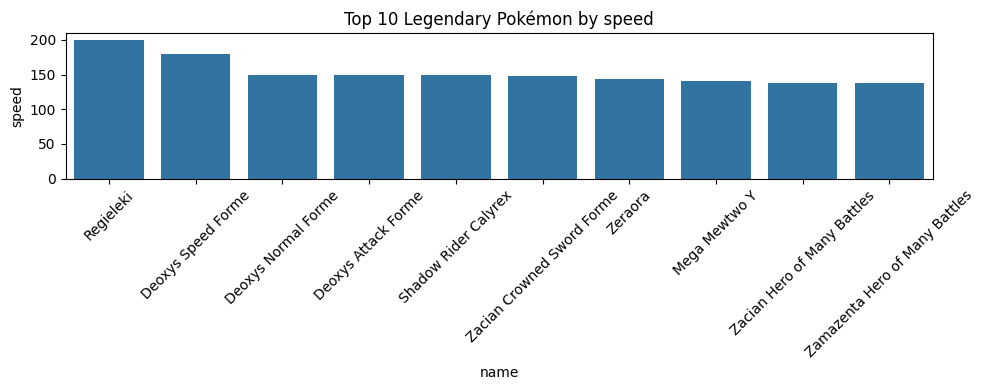

In [19]:
data2 = ['total','hp','attack','defense',
         'sp_attack','sp_defense','speed']
legendary_df = df[df['legendary'] == 1]

for col in data2:
    top10 = legendary_df.nlargest(10, col)

    plt.figure(figsize=(10,4))
    sns.barplot(x=top10['name'], y=top10[col])

    plt.title(f"Top 10 Legendary Pokémon by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

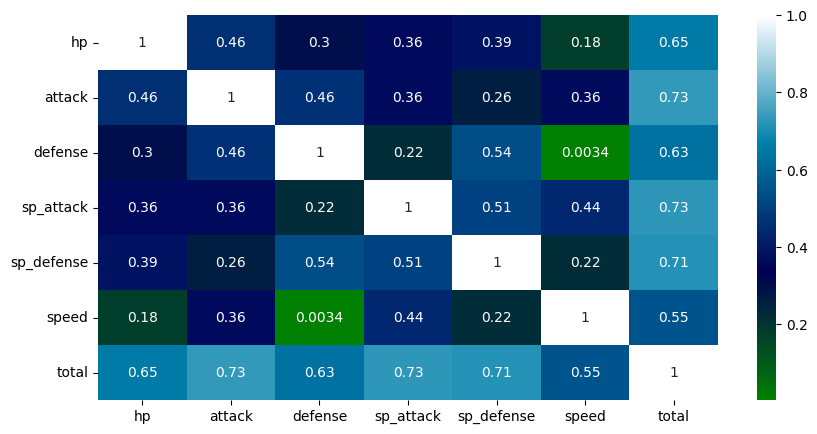

In [20]:
corr = df[['hp','attack','defense',
           'sp_attack','sp_defense',
           'speed','total']].corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True,cmap="ocean")
plt.show()

**---some finding---**
___Legendary Pokémon have significantly higher total stats.
___Dragon, Steel and Psychic types tend to be strongest.
___Bug and Normal types have lower median totals.
___Total stat is positively correlated with all battle stats.
___Some extreme outliers exist among legendary Pokémon